# Hyperparameters and lags search: backtesting vs one-step-ahead

Hyperparameter and lag tuning involves systematically testing different values or combinations of hyperparameters (and/or lags) to find the optimal configuration that gives the best performance. The **skforecast** library provides two different methods to evaluate each candidate configuration:

+ **Backtesting**: In this method, the model predicts several steps ahead in each iteration, using the same forecast horizon and retraining frequency strategy that would be used if the model were deployed. This simulates a real forecasting scenario where the model is retrained and updated over time. More information [here](../user_guides/backtesting.html).

+ **One-Step Ahead**: Evaluates the model using only one-step-ahead predictions. This method is faster because it requires fewer iterations, but it only tests the model's performance in the immediate next time step ($t+1$).

Each method uses a different evaluation strategy, so they may produce different results. However, in the long run, both methods are expected to converge to similar selections of optimal hyperparameters. The one-step-ahead method is much faster than backtesting because it requires fewer iterations, but it only tests the model's performance in the immediate next time step. It is recommended to backtest the final model for a more accurate multi-step performance estimate.

The document compares the performance of these two methods when applied to various datasets and forecaster types. The process is outlined as follows:

+ Optimal hyperparameters and lags are identified through a search using both backtesting and one-step-ahead evaluation methods. This search is performed on the validation partition, and the best configuration is stored along with the time taken to complete the search.

+ Finally, the selected best configuration is evaluated on the test partition using a backtesting procedure.

It is important to note that the final evaluation is consistently performed using backtesting to simulate a real-world multi-step forecasting scenario.

## Results

The results show a significant reduction in the time required to find the optimal configuration using the one-step-ahead method (top panel). However, the performance of the selected configuration on the test partition is similar for both methods (lower panel), with no clear winner. These results are consistent for both grid search and Bayesian search approaches.

<div style="text-align: center;">
    <img src="../img/grid_search_benchmark.png" alt="Grid Search Results" width="700"/>
</div>

<div style="text-align: center;">
    <img src="../img/bayesian_search_benchmark.png" alt="Grid Search Results" width="700"/>
</div>

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

The purpose of this analysis is to compare the time and forecasting performance of the two available evaluation methods, not to compare different forecasters.

</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import platform
import psutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from time import time
from copy import copy
import sklearn
import skforecast
import lightgbm
from lightgbm import LGBMRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from skforecast.datasets import fetch_dataset
from skforecast.plot import set_dark_theme
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, OneStepAheadFold
from skforecast.model_selection import grid_search_forecaster
from skforecast.model_selection import bayesian_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.recursive import ForecasterRecursiveMultiSeries
from skforecast.direct import ForecasterDirectMultiVariate
from skforecast.model_selection import backtesting_forecaster_multiseries
from skforecast.model_selection import grid_search_forecaster_multiseries
from skforecast.model_selection import bayesian_search_forecaster_multiseries
from skforecast.preprocessing import reshape_series_long_to_dict
from skforecast.preprocessing import reshape_exog_long_to_dict

# Warnings
# ==============================================================================
import warnings
from skforecast.exceptions import IgnoredArgumentWarning
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

In [2]:
# Versions
# ==============================================================================
print(f"Python version      : {platform.python_version()}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"skforecast version  : {skforecast.__version__}")
print(f"lightgbm version    : {lightgbm.__version__}")
print(f"pandas version      : {pd.__version__}")
print(f"numpy version       : {np.__version__}")
print("")

# System information
# ==============================================================================
print(f"Machine type: {platform.machine()}")
print(f"Processor type: {platform.processor()}")
print(f"Platform type: {platform.platform()}")
print(f"Operating system: {platform.system()}")
print(f"Operating system release: {platform.release()}")
print(f"Operating system version: {platform.version()}")
print(f"Number of physical cores: {psutil.cpu_count(logical=False)}")
print(f"Number of logical cores: {psutil.cpu_count(logical=True)}")

Python version      : 3.14.3
scikit-learn version: 1.9.1
skforecast version  : 0.26.0
lightgbm version    : 4.6.0
pandas version      : 2.3.3
numpy version       : 2.5.3

Machine type: arm64
Processor type: arm
Platform type: macOS-27.0.1-arm64-arm-64bit-Mach-O
Operating system: Darwin
Operating system release: 27.0.0
Operating system version: Darwin Kernel Version 27.0.0: Tue Aug 11 21:02:59 PDT 2026; root:xnu-13432.1.9~1/RELEASE_ARM64_T8142
Number of physical cores: 10
Number of logical cores: 10


In [3]:
# Import data
# ==============================================================================
data_bike = fetch_dataset('bike_sharing_extended_features', verbose=False)

data_sales = fetch_dataset(name="items_sales", verbose=False)
data_sales = data_sales * 100
data_sales['day_of_week'] = data_sales.index.dayofweek

data_website = fetch_dataset(name="website_visits", raw=True, verbose=False)
data_website['date'] = pd.to_datetime(data_website['date'], format='%d/%m/%y')
data_website = data_website.set_index('date')
data_website = data_website.asfreq('1D')
data_website = data_website.sort_index()
data_website['month'] = data_website.index.month
data_website['month_day'] = data_website.index.day
data_website['week_day'] = data_website.index.day_of_week
data_website = pd.get_dummies(data_website, columns=['month', 'week_day', 'month_day'], dtype='int64')

data_electricity = fetch_dataset(name='vic_electricity', raw=False, verbose=False)
data_electricity = data_electricity.drop(columns="Date")
data_electricity = (
    data_electricity
    .resample(rule="h", closed="left", label="right")
    .agg({
        "Demand": "mean",
        "Temperature": "mean",
        "Holiday": "mean",
    })
)
data_electricity = data_electricity.loc['2012-01-01 00:00:00': '2013-12-30 23:00:00'].copy()

series_dict = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series.csv'
)
exog_dict = pd.read_csv(
    'https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/demo_multi_series_exog.csv'
)
series_dict['timestamp'] = pd.to_datetime(series_dict['timestamp'])
exog_dict['timestamp'] = pd.to_datetime(exog_dict['timestamp'])

series_dict = reshape_series_long_to_dict(
    data      = series_dict,
    series_id = 'series_id',
    index     = 'timestamp',
    values    = 'value',
    freq      = 'D'
)
exog_dict = reshape_exog_long_to_dict(
    data      = exog_dict,
    series_id = 'series_id',
    index     = 'timestamp',
    freq      = 'D'
)

## Benchmark

In [4]:
# Functions to compare results using backtesting and one step ahead
# ==============================================================================
def run_benchmark(
    data,
    forecaster_to_benchmark,
    search_method = None,
    lags_grid = None,
    param_grid = None,
    search_space = None,
    end_train = None,
    end_validation = None,
    target = None,
    exog_features = None,
    steps = None,
    metric = None
):
    """
    Compare results of grid search and bayesian search using backtesting and one-step-ahead.
    """
    
    # backtesting
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_train]),
            steps              = steps,
            refit              = False,
         )
    if search_method == 'grid_search':
        results_1 = grid_search_forecaster(
                        forecaster    = forecaster,
                        y             = data.loc[:end_validation, target],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        n_jobs        = 'auto',
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_1, _ = bayesian_search_forecaster(
                           forecaster    = forecaster,
                           y             = data.loc[:end_validation, target],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           n_jobs        = 'auto',
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_1 = end - start
    best_params = results_1.loc[0, 'params']
    best_lags = results_1.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_1, _ = backtesting_forecaster(
                      forecaster    = forecaster,
                      y             = data.loc[:, target],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    # One step ahead
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = OneStepAheadFold(initial_train_size = len(data.loc[:end_train]))
    if search_method == 'grid_search':
        results_2 = grid_search_forecaster(
                        forecaster    = forecaster,
                        y             = data.loc[:end_validation, target],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_2, _ = bayesian_search_forecaster(
                           forecaster    = forecaster,
                           y             = data.loc[:end_validation, target],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_2 = end - start
    best_params = results_2.loc[0, 'params']
    best_lags = results_2.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_2, _ = backtesting_forecaster(
                      forecaster    = forecaster,
                      y             = data.loc[:, target],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    print("-----------------")
    print("Benchmark results")
    print("-----------------")
    print('Execution time backtesting   :', time_1)
    print('Execution time one step ahead:', time_2)
    print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
    print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
    print("")
    print("Method: backtesting")
    print(f"    lags   : {results_1.loc[0, 'lags']}")
    print(f"    params : {results_1.loc[0, 'params']}")
    print(f"    {metric}: {metric_1.loc[0, metric]}")
    print("")
    print("Method: one step ahead")
    print(f"    lags   : {results_2.loc[0, 'lags']}")
    print(f"    params : {results_2.loc[0, 'params']}")
    print(f"    {metric}: {metric_2.loc[0, metric]}")
    
    return time_1, time_2, metric_1.loc[0, metric], metric_2.loc[0, metric]


# Functions to compare results using backtesting and one step ahead
# ==============================================================================
def run_benchmark_multiseries(
    data = None,
    forecaster_to_benchmark = None,
    search_method = None,
    lags_grid = None,
    param_grid = None,
    search_space = None,
    end_train = None,
    end_validation = None,
    levels = None,
    exog_features = None,
    steps = None,
    metric = None
):
    """
    Compare results of grid search using backtesting and one-step-ahead.
    """
    
    # Backtesting
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = TimeSeriesFold(
                initial_train_size = len(data.loc[:end_train]),
                steps              = steps,
                refit              = False,
             )
    if search_method == 'grid_search':
        results_1 = grid_search_forecaster_multiseries(
                        forecaster    = forecaster,
                        series        = data.loc[:end_validation, levels],
                        levels        = levels,
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        n_jobs        = 'auto',
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_1, _ = bayesian_search_forecaster_multiseries(
                           forecaster    = forecaster,
                           series        = data.loc[:end_validation, levels],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           levels        = levels,
                           search_space  = search_space,
                           cv            = cv,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           n_jobs        = 'auto',
                           verbose       = False,
                           show_progress = False
                       )
    end = time()
    time_1 = end - start
    best_params = results_1.loc[0, 'params']
    best_lags = results_1.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_1, _ = backtesting_forecaster_multiseries(
                      forecaster    = forecaster,
                      series        = data.loc[:, levels],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      levels        = levels,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    # One step ahead
    forecaster = copy(forecaster_to_benchmark)
    start  = time()
    cv = OneStepAheadFold(initial_train_size = len(data.loc[:end_train]))
    if search_method == 'grid_search':
        results_2 = grid_search_forecaster_multiseries(
                        forecaster    = forecaster,
                        series        = data.loc[:end_validation, levels],
                        exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                        cv            = cv,
                        levels        = levels,
                        param_grid    = param_grid,
                        lags_grid     = lags_grid,
                        metric        = metric,
                        return_best   = False,
                        verbose       = False,
                        show_progress = False
                    )
    else:
        results_2, _ = bayesian_search_forecaster_multiseries(
                           forecaster    = forecaster,
                           series        = data.loc[:end_validation, levels],
                           exog          = data.loc[:end_validation, exog_features] if exog_features else None,
                           cv            = cv,
                           levels        = levels,
                           search_space  = search_space,
                           metric        = metric,
                           n_trials      = 15,
                           random_state  = 123,
                           return_best   = False,
                           verbose       = False,
                           show_progress = False
                       )

    end = time()
    time_2 = end - start
    best_params = results_2.loc[0, 'params']
    best_lags = results_2.loc[0, 'lags']
    forecaster.set_params(best_params)
    forecaster.set_lags(lags=best_lags)
    cv = TimeSeriesFold(
            initial_train_size = len(data.loc[:end_validation]),
            steps              = steps,
            refit              = False,
         )
    metric_2, _ = backtesting_forecaster_multiseries(
                      forecaster    = forecaster,
                      series        = data.loc[:, levels],
                      exog          = data.loc[:, exog_features] if exog_features else None,
                      cv            = cv,
                      levels        = levels,
                      metric        = metric,
                      verbose       = False,
                      show_progress = False
                  )

    print("Benchmark results")
    print("-----------------")
    print('Execution time backtesting   :', time_1)
    print('Execution time one step ahead:', time_2)
    print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
    print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
    print("")
    print("Method: backtesting")
    print(f"    lags   : {results_1.loc[0, 'lags']}")
    print(f"    params : {results_1.loc[0, 'params']}")
    print(f"    {metric_1.loc[0, metric]}")
    print("")
    print("Method: one step ahead")
    print(f"    lags   : {results_2.loc[0, 'lags']}")
    print(f"    params : {results_2.loc[0, 'params']}")
    print(f"    {metric_2.loc[0, metric]}")
    
    return time_1, time_2, metric_1.loc[0, metric], metric_2.loc[0, metric]


def summarize_results(results, metric, title, plot=True, save_plot=None, fig_size=(8, 4)):
    """
    Summarize results of benchmark.
    """

    results = pd.DataFrame(
        results,
        columns=[
            "dataset",
            "forecaster",
            "time_search_backtesting",
            "time_search_one_step",
            "metric_backtesting",
            "metric_one_step",
        ]
    )
    results['ratio_speed'] = (
        results['time_search_backtesting'] / results['time_search_one_step']
    ).round(2)
    results['ratio_metric'] = (
        results['metric_backtesting'] / results['metric_one_step']
    ).round(2)
    results["dataset_forecaster"] = (
        results["dataset"]
        + " \n "
        + results["forecaster"].str.replace("Forecaster", "")
    )
    display(results)

    if plot:
        set_dark_theme()
        fig, axs = plt.subplots(2, 1, figsize=fig_size, sharex=True)
        results.plot.bar(
            x='dataset_forecaster',
            y=['time_search_backtesting', 'time_search_one_step'],
            ax=axs[0],
        )
        axs[0].set_ylabel('time (s)')
        axs[0].legend(["backtesting", "one-step-ahead"])
        results.plot.bar(
            x='dataset_forecaster',
            y=['metric_backtesting', 'metric_one_step'],
            ax=axs[1],
            legend=False
        )
        axs[1].set_ylabel(f'{metric}')
        axs[1].set_xlabel('')
        plt.xticks(rotation=90)
        plt.suptitle(title)
        plt.tight_layout()

        if save_plot:
            plt.savefig(save_plot, dpi=300, bbox_inches='tight')

### Grid search

In [5]:
# Results
# ==============================================================================
results_grid_search = []
metric = 'mean_absolute_error'

In [6]:
# Dataset bike_sharing_extended_features - ForecasterRecursive
# ==============================================================================
end_train = '2012-03-31 23:59:00'
end_validation = '2012-08-31 23:59:00'
exog_features = [
    'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'week_day_sin',
    'week_day_cos', 'hour_day_sin', 'hour_day_cos', 'sunrise_hour_sin', 'sunrise_hour_cos',
    'sunset_hour_sin', 'sunset_hour_cos', 'holiday_previous_day', 'holiday_next_day',
    'temp_roll_mean_1_day', 'temp_roll_mean_7_day', 'temp_roll_max_1_day',
    'temp_roll_min_1_day', 'temp_roll_max_7_day', 'temp_roll_min_7_day',
    'temp', 'holiday'
]

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )
lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_grid_search.append([
    'bike',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 12.694831848144531
Execution time one step ahead: 8.233110189437866
Same lags   : False
Same params : True

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
    mean_absolute_error: 58.276762590192014

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
    mean_absolute_error: 64.04254202108999


In [7]:
# Dataset bike_sharing_extended_features - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'bike',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 6.455695867538452
Execution time one step ahead: 0.1428821086883545
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(112.88378916846884)}
    mean_absolute_error: 79.14111581771647

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'alpha': np.float64(12.742749857031322)}
    mean_absolute_error: 111.95615163625355


In [8]:
# Dataset website_visits - ForecasterRecursive
# ==============================================================================
end_train = '2021-03-30 23:59:00'
end_validation = '2021-06-30 23:59:00'
exog_features = [col for col in data_website.columns if col.startswith(('month_', 'week_day_', 'month_day_'))]

forecaster = ForecasterRecursive(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)
results_grid_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.44190502166748047
Execution time one step ahead: 0.04010820388793945
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 162.11396980738866

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(2.976351441631316)}
    mean_absolute_error: 162.35163466017457


In [9]:
# Dataset website_visits - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator = Ridge(random_state=123),
                 steps     = 24,
                 lags      = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.9309570789337158
Execution time one step ahead: 0.0812978744506836
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 277.8362513175124

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': np.float64(1.438449888287663)}
    mean_absolute_error: 236.28560218972396


In [10]:
# Dataset vic_electricity - ForecasterRecursive
# ==============================================================================
end_train = '2013-06-30 23:59:00'
end_validation = '2013-11-30 23:59:00'
exog_features = ['Temperature', 'Holiday']

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 12.100318908691406
Execution time one step ahead: 7.48112678527832
Same lags   : False
Same params : True

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
    mean_absolute_error: 194.83553235066182

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
    mean_absolute_error: 188.8782299908785


In [11]:
# Dataset vic_electricity - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]

param_grid = {'alpha': np.logspace(-3, 3, 20)}

time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)
results_grid_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 4.756232023239136
Execution time one step ahead: 0.1128077507019043
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(6.158482110660261)}
    mean_absolute_error: 304.22332781257046

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': np.float64(1.438449888287663)}
    mean_absolute_error: 301.7070971763038


In [12]:
# Dataset sales - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2014-05-15 23:59:00'
end_validation = '2014-07-15 23:59:00'
levels = ['item_1', 'item_2', 'item_3']
exog_features = ['day_of_week']

forecaster = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = {
    '24 lags': 24,
    '48 lags': 48
}

param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 36,
    metric                  = metric
)
results_grid_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 1.6738948822021484
Execution time one step ahead: 1.5797171592712402
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
    params : {'max_depth': 7, 'n_estimators': 200}
    137.16940500432474

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'max_depth': 3, 'n_estimators': 50}
    134.76669158338447


In [13]:
# Dataset sales - ForecasterDirectMultiVariate
# ==============================================================================
forecaster = ForecasterDirectMultiVariate(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 steps              = 5,
                 level              = 'item_1',
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = {
    '24 lags': 24,
    '48 lags': 48
}

param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'grid_search',
    lags_grid               = lags_grid,
    param_grid              = param_grid,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 5,
    metric                  = metric
)

results_grid_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 6.511770963668823
Execution time one step ahead: 1.230621099472046
Same lags   : False
Same params : True

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
    params : {'max_depth': 7, 'n_estimators': 50}
    100.1644114641031

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'max_depth': 7, 'n_estimators': 50}
    95.20010578089475


In [14]:
# Dataset series_dict - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2016-05-31 23:59:00'
end_validation = '2016-07-31 23:59:00'
levels = ['id_1000', 'id_1001', 'id_1002', 'id_1003', 'id_1004']
series_dict_train = {k: v.loc[: end_train,] for k, v in series_dict.items()}
exog_dict_train   = {k: v.loc[: end_train,] for k, v in exog_dict.items()}
series_dict_test  = {k: v.loc[end_train:,] for k, v in series_dict.items()}
exog_dict_test    = {k: v.loc[end_train:,] for k, v in exog_dict.items()}

forecaster_to_benchmark = ForecasterRecursiveMultiSeries(
                              estimator          = LGBMRegressor(random_state=123, verbose=-1),
                              lags               = 24,
                              encoding           = "ordinal",
                              transformer_series = None,
                              transformer_exog   = None,
                              weight_func        = None,
                              series_weights     = None,
                              differentiation    = None,
                              dropna_from_series = False,
                              fit_kwargs         = None,
                              forecaster_id      = None
                          )
lags_grid = [7, 14]
param_grid = {
    'n_estimators': [50, 200],
    'max_depth': [3, 7]
}

# Backtesting
forecaster = copy(forecaster_to_benchmark)
start  = time()
cv = TimeSeriesFold(
        initial_train_size = 100,
        steps              = 24,
        refit              = False
     )
results_1 = grid_search_forecaster_multiseries(
                forecaster        = forecaster,
                series            = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                exog              = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                cv                = cv,
                param_grid        = param_grid,
                lags_grid         = lags_grid,
                metric            = metric,
                return_best       = False,
                n_jobs            = 'auto',
                verbose           = False,
                show_progress     = False,
                suppress_warnings = True
            )
end = time()
time_1 = end - start
best_params = results_1.loc[0, 'params']
best_lags = results_1.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)
cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False
     )
metric_1, pred_1 = backtesting_forecaster_multiseries(
                       forecaster        = forecaster,
                       series            = series_dict,
                       exog              = exog_dict,
                       cv                = cv,
                       levels            = levels,
                       metric            = metric,
                       verbose           = False,
                       show_progress     = False,
                       suppress_warnings = True
                   )

# One step ahead
forecaster = copy(forecaster_to_benchmark)
start  = time()
cv = OneStepAheadFold(initial_train_size = 100)
results_2 = grid_search_forecaster_multiseries(
                forecaster        = forecaster,
                series            = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                exog              = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                cv                = cv,
                levels            = levels,
                param_grid        = param_grid,
                lags_grid         = lags_grid,
                metric            = metric,
                return_best       = False,
                verbose           = False,
                show_progress     = False,
                suppress_warnings = True
            )
end = time()
time_2 = end - start
best_params = results_2.loc[0, 'params']
best_lags = results_2.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)
cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False
     )
metric_2, pred_2 = backtesting_forecaster_multiseries(
                       forecaster        = forecaster,
                       series            = series_dict,
                       exog              = exog_dict,
                       cv                = cv,
                       levels            = levels,
                       metric            = metric,
                       verbose           = False,
                       show_progress     = False,
                       suppress_warnings = True
                   )

print("Benchmark results")
print("-----------------")
print('Execution time backtesting   :', time_1)
print('Execution time one step ahead:', time_2)
print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
print("")
print("Method: backtesting")
print(f"    lags   : {results_1.loc[0, 'lags']}")
print(f"    params : {results_1.loc[0, 'params']}")
print(f"    {metric_1.loc[0, metric]}")
print("")
print("Method: one step ahead")
print(f"    lags   : {results_2.loc[0, 'lags']}")
print(f"    params : {results_2.loc[0, 'params']}")
print(f"    {metric_2.loc[0, metric]}")

results_grid_search.append([
    'series_dict',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1.loc[0, metric],
    metric_2.loc[0, metric],
])

Benchmark results
-----------------
Execution time backtesting   : 0.815040111541748
Execution time one step ahead: 0.7078478336334229
Same lags   : False
Same params : False

Method: backtesting
    lags   : [1 2 3 4 5 6 7]
    params : {'max_depth': 3, 'n_estimators': 50}
    180.46141171905165

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'max_depth': 7, 'n_estimators': 50}
    164.23659500870002


,dataset,forecaster,time_search_backtesting,time_search_one_step,metric_backtesting,metric_one_step,ratio_speed,ratio_metric,dataset_forecaster
0,bike,ForecasterRecursive,12.694832,8.233110,58.276763,64.042542,1.54,0.91,bike \n Recursive
1,bike,ForecasterDirect,6.455696,0.142882,79.141116,111.956152,45.18,0.71,bike \n Direct
2,website,ForecasterRecursive,0.441905,0.040108,162.113970,162.351635,11.02,1.00,website \n Recursive
3,website,ForecasterDirect,0.930957,0.081298,277.836251,236.285602,11.45,1.18,website \n Direct
4,electricity,ForecasterRecursive,12.100319,7.481127,194.835532,188.878230,1.62,1.03,electricity \n Recursive
5,electricity,ForecasterDirect,4.756232,0.112808,304.223328,301.707097,42.16,1.01,electricity \n Direct
6,sales,ForecasterRecursiveMultiSeries,1.673895,1.579717,137.169405,134.766692,1.06,1.02,sales \n RecursiveMultiSeries
7,sales,ForecasterDirectMultiVariate,6.511771,1.230621,100.164411,95.200106,5.29,1.05,sales \n DirectMultiVariate
8,series_dict,ForecasterRecursiveMultiSeries,0.815040,0.707848,180.461412,164.236595,1.15,1.10,series_dict \n RecursiveMultiSeries


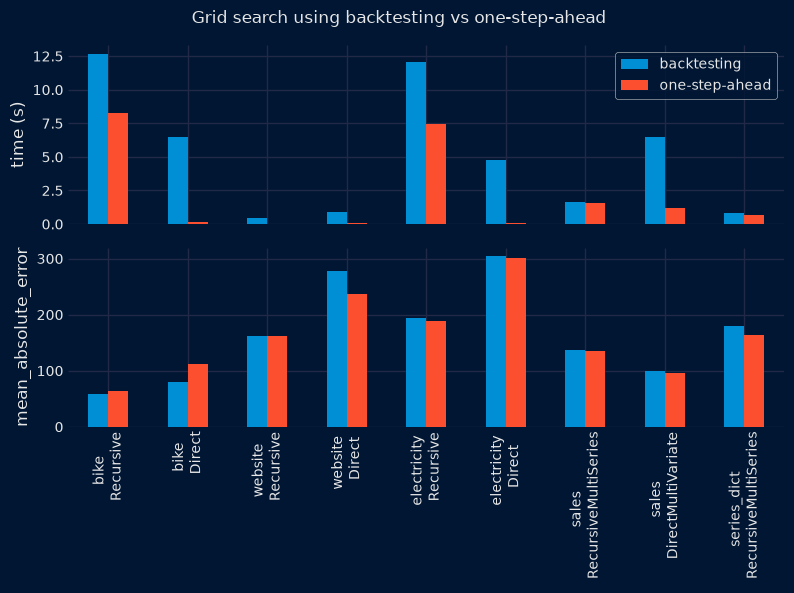

In [15]:
# Results
# ==============================================================================
summarize_results(
    results   = results_grid_search,
    metric    = metric,
    plot      = True,
    fig_size  = (8, 6),
    title     = 'Grid search using backtesting vs one-step-ahead',
    save_plot = "../img/grid_search_benchmark.png"
)

### Bayesian search

In [16]:
# Table to store results
# ==============================================================================
results_bayesian_search = []
metric = 'mean_absolute_error'

In [17]:
# Dataset bike_sharing_extended_features - ForecasterRecursive
# ==============================================================================
end_train = '2012-03-31 23:59:00'
end_validation = '2012-08-31 23:59:00'
exog_features = [
    'month_sin', 'month_cos', 'week_of_year_sin', 'week_of_year_cos', 'week_day_sin',
    'week_day_cos', 'hour_day_sin', 'hour_day_cos', 'sunrise_hour_sin', 'sunrise_hour_cos',
    'sunset_hour_sin', 'sunset_hour_cos', 'holiday_previous_day', 'holiday_next_day',
    'temp_roll_mean_1_day', 'temp_roll_mean_7_day', 'temp_roll_max_1_day',
    'temp_roll_min_1_day', 'temp_roll_max_7_day', 'temp_roll_min_7_day',
    'temp', 'holiday'
]

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'gamma'        : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'bike_sharing',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 51.704978942871094
Execution time one step ahead: 41.652785301208496
Same lags   : True
Same params : False

Method: backtesting
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'n_estimators': 1200, 'max_depth': 10, 'learning_rate': 0.01663211619538342, 'gamma': 0.9044583859363924, 'reg_alpha': 0.16016980526911567, 'reg_lambda': 0.24572731754447144}
    mean_absolute_error: 55.32660887147895

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'n_estimators': 700, 'max_depth': 9, 'learning_rate': 0.02661029021165061, 'gamma': 0.890050989934274, 'reg_alpha': 0.030390634163454583, 'reg_lambda': 0.1736647223355085}
    mean_absolute_error: 55.73026623098923


In [18]:
# Dataset bike_sharing_extended_features - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 steps         = 24,
                 lags          = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_bike,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'bike_sharing',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 1.4610991477966309
Execution time one step ahead: 0.04563307762145996
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 236.0507236643537}
    mean_absolute_error: 79.30654504560904

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'alpha': 10.831164425622006}
    mean_absolute_error: 111.95081459205066


In [19]:
# Dataset website_visits - ForecasterRecursive
# ==============================================================================
end_train = '2021-03-30 23:59:00'
end_validation = '2021-06-30 23:59:00'
exog_features = [col for col in data_website.columns if col.startswith(('month_', 'week_day_', 'month_day_'))]

forecaster = ForecasterRecursive(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10
             )

lags_grid = [7, 14, 21, [7, 14, 21]]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    } 
    
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)

results_bayesian_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.0858619213104248
Execution time one step ahead: 0.015182733535766602
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
    params : {'alpha': 0.7775392695714586}
    mean_absolute_error: 134.65893719878372

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': 1.6754061464799228}
    mean_absolute_error: 165.40723118398483


In [20]:
# Dataset website_visits - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10,
                 steps         = 7
             )

lags_grid = [7, 14, 21, [7, 14, 21]]


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    } 
    
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_website,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'users',
    exog_features           = exog_features,
    steps                   = 7,
    metric                  = metric
)

results_bayesian_search.append([
    'website',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 0.12271571159362793
Execution time one step ahead: 0.01715087890625
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
    params : {'alpha': 0.7775392695714586}
    mean_absolute_error: 135.53428185038518

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'alpha': 1.6754061464799228}
    mean_absolute_error: 149.1378317285512


In [21]:
# Dataset vic_electricity - ForecasterRecursive
# ==============================================================================
end_train = '2013-06-30 23:59:00'
end_validation = '2013-11-30 23:59:00'
exog_features = ['Temperature', 'Holiday']

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 10
             )

lags_grid = [48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169)]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'gamma'        : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 41.517783880233765
Execution time one step ahead: 40.903043270111084
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.04461611381289602, 'gamma': 0.7718470878550808, 'reg_alpha': 0.5496892665109754, 'reg_lambda': 0.08960735671949432}
    mean_absolute_error: 201.51496087216307

Method: one step ahead
    lags   : [  1   2   3  23  24  25 167 168 169]
    params : {'n_estimators': 1000, 'max_depth': 9, 'learning_rate': 0.09236303844911438, 'gamma': 0.7636828414433382, 'reg_alpha': 0.243666374536874, 'reg_lambda': 0.19422296057877086}
    mean_absolute_error: 192.32500930008734


In [22]:
# Dataset vic_electricity - ForecasterDirect
# ==============================================================================
forecaster = ForecasterDirect(
                 estimator     = Ridge(random_state=123),
                 transformer_y = StandardScaler(),
                 lags          = 10,
                 steps         = 24
             )

lags_grid = (48, 72, (1, 2, 3, 23, 24, 25, 167, 168, 169))


def search_space(trial):
    search_space  = {
        'alpha': trial.suggest_float('alpha', 0.001, 1000, log=True),
        'lags' : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark(
    data                    = data_electricity,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    target                  = 'Demand',
    exog_features           = exog_features,
    steps                   = 24,
    metric                  = metric
)

results_bayesian_search.append([
    'electricity',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

-----------------
Benchmark results
-----------------
Execution time backtesting   : 1.3004968166351318
Execution time one step ahead: 0.04372715950012207
Same lags   : True
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 5.991912801723464}
    mean_absolute_error: 304.1576277530811

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'alpha': 2.5635960787402294}
    mean_absolute_error: 302.4647742884971


In [23]:
# Dataset sales - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2014-05-15 23:59:00'
end_validation = '2014-07-15 23:59:00'
levels = ['item_1', 'item_2', 'item_3']
exog_features = ['day_of_week']

forecaster = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = [48, 72]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    } 
    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 36,
    metric                  = metric
)

results_bayesian_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 3.455744981765747
Execution time one step ahead: 3.9083590507507324
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'n_estimators': 51, 'max_depth': 5, 'learning_rate': 0.06422546312681227}
    124.6074832551834

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 179, 'max_depth': 5, 'learning_rate': 0.0438929974747467}
    113.16460939399659


In [24]:
# Dataset sales - ForecasterDirectMultiVariate
# ==============================================================================
forecaster = ForecasterDirectMultiVariate(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 steps              = 5,
                 level              = 'item_1',
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )

lags_grid = [48, 72]


def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 50, 200),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 1),
        'lags'         : trial.suggest_categorical('lags', lags_grid)
    }

    return search_space


time_1, time_2, metric_1, metric_2 = run_benchmark_multiseries(
    data                    = data_sales,
    forecaster_to_benchmark = forecaster,
    search_method           = 'bayesian_search',
    search_space            = search_space,
    end_train               = end_train,
    end_validation          = end_validation,
    levels                  = levels,
    exog_features           = exog_features,
    steps                   = 5,
    metric                  = metric
)

results_bayesian_search.append([
    'sales',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1,
    metric_2,
])

Benchmark results
-----------------
Execution time backtesting   : 17.453059196472168
Execution time one step ahead: 2.9149980545043945
Same lags   : False
Same params : False

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48]
    params : {'n_estimators': 177, 'max_depth': 3, 'learning_rate': 0.04623508546672095}
    99.57897402912161

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48
 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72]
    params : {'n_estimators': 63, 'max_depth': 7, 'learning_rate': 0.1506426227438349}
    104.52333919423985


In [25]:
# Dataset series_dict - ForecasterRecursiveMultiSeries
# ==============================================================================
end_train = '2016-05-31 23:59:00'
end_validation = '2016-07-31 23:59:00'
levels = ['id_1000', 'id_1001', 'id_1002', 'id_1003', 'id_1004']
series_dict_train = {k: v.loc[: end_train,] for k, v in series_dict.items()}
exog_dict_train   = {k: v.loc[: end_train,] for k, v in exog_dict.items()}
series_dict_test  = {k: v.loc[end_train:,] for k, v in series_dict.items()}
exog_dict_test    = {k: v.loc[end_train:,] for k, v in exog_dict.items()}

forecaster_to_benchmark = ForecasterRecursiveMultiSeries(
                 estimator          = LGBMRegressor(random_state=123, verbose=-1),
                 lags               = 24,
                 encoding           = "ordinal",
                 transformer_series = None,
                 transformer_exog   = None,
                 weight_func        = None,
                 series_weights     = None,
                 differentiation    = None,
                 dropna_from_series = False,
                 fit_kwargs         = None,
                 forecaster_id      = None
             )


def search_space(trial):
    search_space  = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth'   : trial.suggest_int('max_depth', 3, 7, step=1),
        'lags'        : trial.suggest_categorical('lags', [7, 14])
    } 
    return search_space


# Backtesting
forecaster = copy(forecaster_to_benchmark)
cv = TimeSeriesFold(
        initial_train_size = 100,
        steps              = 24,
        refit              = False,
     )
start  = time()
results_1, _ = bayesian_search_forecaster_multiseries(
                   forecaster         = forecaster,
                   series             = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                   exog               = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                   cv                 = cv,
                   search_space       = search_space,
                   n_trials           = 10,
                   metric             = metric,
                   return_best        = False,
                   n_jobs             = 'auto',
                   verbose            = False,
                   show_progress      = False,
                   suppress_warnings  = True
               )
end = time()
time_1 = end - start
best_params = results_1.loc[0, 'params']
best_lags = results_1.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)

cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False,
     )
metric_1, pred_1 = backtesting_forecaster_multiseries(
                       forecaster         = forecaster,
                       series             = series_dict,
                       exog               = exog_dict,
                       cv                 = cv,
                       levels             = levels,
                       metric             = metric,
                       verbose            = False,
                       show_progress      = False,
                       suppress_warnings  = True
                   )

# One step ahead
forecaster = copy(forecaster_to_benchmark)
cv = OneStepAheadFold(initial_train_size = 100)
start  = time()
results_2, _ = bayesian_search_forecaster_multiseries(
                   forecaster         = forecaster,
                   series             = {k: v.loc[: end_validation,] for k, v in series_dict.items()},
                   exog               = {k: v.loc[: end_validation,] for k, v in exog_dict.items()},
                   cv                 = cv,
                   levels             = levels,
                   search_space       = search_space,
                   n_trials           = 10,
                   metric             = metric,
                   return_best        = False,
                   verbose            = False,
                   show_progress      = False,
                   suppress_warnings  = True
               )
end = time()
time_2 = end - start
best_params = results_2.loc[0, 'params']
best_lags = results_2.loc[0, 'lags']
forecaster.set_params(best_params)
forecaster.set_lags(lags=best_lags)

cv = TimeSeriesFold(
        initial_train_size = 213,
        steps              = 24,
        refit              = False,
     )
metric_2, pred_2 = backtesting_forecaster_multiseries(
                       forecaster         = forecaster,
                       series             = series_dict,
                       exog               = exog_dict,
                       cv                 = cv,
                       levels             = levels,
                       metric             = metric,
                       verbose            = False,
                       show_progress      = False,
                       suppress_warnings  = True
                   )

print("Benchmark results")
print("-----------------")
print('Execution time backtesting   :', time_1)
print('Execution time one step ahead:', time_2)
print(f"Same lags   : {np.array_equal(results_1.loc[0, 'lags'], results_2.loc[0, 'lags'])}")
print(f"Same params : {results_1.loc[0, 'params'] == results_2.loc[0, 'params']}")
print("")
print("Method: backtesting")
print(f"    lags   : {results_1.loc[0, 'lags']}")
print(f"    params : {results_1.loc[0, 'params']}")
print(f"    {metric_1.loc[0, metric]}")
print("")
print("Method: one step ahead")
print(f"    lags   : {results_2.loc[0, 'lags']}")
print(f"    params : {results_2.loc[0, 'params']}")
print(f"    {metric_2.loc[0, metric]}")

results_bayesian_search.append([
    'series_dict',
    type(forecaster).__name__,
    time_1,
    time_2,
    metric_1.loc[0, metric],
    metric_2.loc[0, metric],
])

Benchmark results
-----------------
Execution time backtesting   : 1.0744609832763672
Execution time one step ahead: 0.8619709014892578
Same lags   : True
Same params : True

Method: backtesting
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'n_estimators': 77, 'max_depth': 3}
    208.60243551060555

Method: one step ahead
    lags   : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
    params : {'n_estimators': 77, 'max_depth': 3}
    208.60243551060555


,dataset,forecaster,time_search_backtesting,time_search_one_step,metric_backtesting,metric_one_step,ratio_speed,ratio_metric,dataset_forecaster
0,bike_sharing,ForecasterRecursive,51.704979,41.652785,55.326609,55.730266,1.24,0.99,bike_sharing \n Recursive
1,bike_sharing,ForecasterDirect,1.461099,0.045633,79.306545,111.950815,32.02,0.71,bike_sharing \n Direct
2,website,ForecasterRecursive,0.085862,0.015183,134.658937,165.407231,5.66,0.81,website \n Recursive
3,website,ForecasterDirect,0.122716,0.017151,135.534282,149.137832,7.16,0.91,website \n Direct
4,electricity,ForecasterRecursive,41.517784,40.903043,201.514961,192.325009,1.02,1.05,electricity \n Recursive
5,electricity,ForecasterDirect,1.300497,0.043727,304.157628,302.464774,29.74,1.01,electricity \n Direct
6,sales,ForecasterRecursiveMultiSeries,3.455745,3.908359,124.607483,113.164609,0.88,1.10,sales \n RecursiveMultiSeries
7,sales,ForecasterDirectMultiVariate,17.453059,2.914998,99.578974,104.523339,5.99,0.95,sales \n DirectMultiVariate
8,series_dict,ForecasterRecursiveMultiSeries,1.074461,0.861971,208.602436,208.602436,1.25,1.00,series_dict \n RecursiveMultiSeries


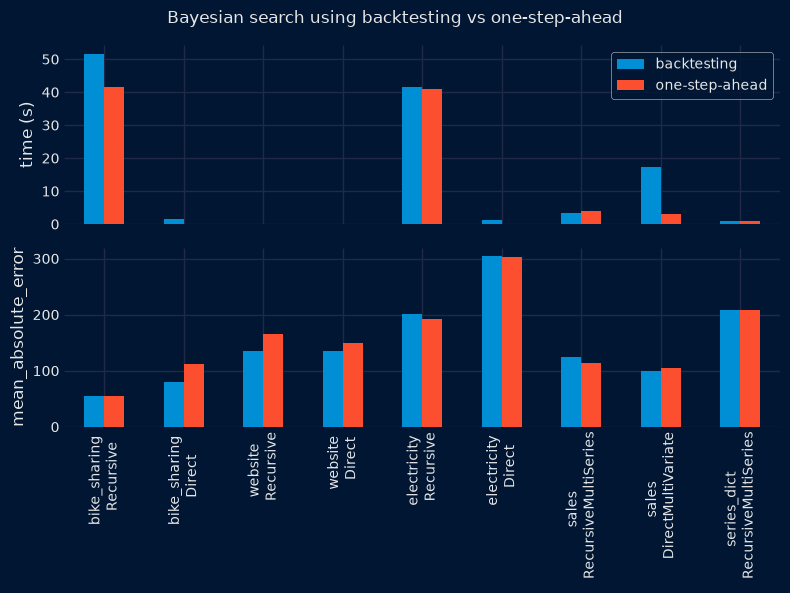

In [26]:
# Results
# ==============================================================================
summarize_results(
    results   = results_bayesian_search,
    metric    = metric,
    plot      = True,
    fig_size  = (8, 6),
    title     = 'Bayesian search using backtesting vs one-step-ahead',
    save_plot = "../img/bayesian_search_benchmark.png"
)